In [1]:
import sys
sys.path.append('src')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

from kalman_tracker import KalmanFilter
from state_logger import StateLogger
from state_permuter import StatePermuter


# **Kalman‑Based Multi‑Object Tracking on Synthetic 2D Trajectories**

**Description:** In this first part, "Kalman‑Based MOT: Theory and Model", we focus on the theoretical foundations and motion modelling behind the tracker. We introduce the multi‑object tracking setting, define the 2D state representation for individual objects (position and velocity, optionally acceleration), and derive the corresponding motion and measurement models in discrete time. We then embed these models into the linear Kalman filter framework and explain how each object can be represented by its own Kalman filter instance. The outcome of this part is a well‑specified single‑object tracking module and a conceptual extension to multiple objects, which will later be implemented, visualised, and evaluated on synthetic 2D trajectories in the subsequent parts of the project.

## **Theory and Motion Modeling for Kalman‑Based Multi‑Object Tracking in 2D**

## Introduction

The Kalman filter is a recursive algorithm for estimating the state of a dynamic system from a sequence of noisy observations. At each time step it alternates between two operations: a **prediction** — where the next state is forecasted from a motion model — and an **update** — where that forecast is corrected using a new sensor measurement. The balance between the two is governed by the *Kalman gain*, which weighs model confidence against measurement reliability automatically.

This notebook builds the filter from first principles for a **2D tracking problem**, where the state of a moving object is described by its position, velocity, and acceleration:
$$\mathbf{s}_k = [x,\; y,\; v_x,\; v_y,\; a_x,\; a_y]^\top$$

**Motivation — GPS noise.** Consumer GPS receivers report position with an  error of roughly 4–10 metres, even under good conditions. When a vehicle is tracked at 1-second intervals, this noise makes the raw trajectory jagged: instantaneous speed estimates fluctuate wildly and the path appears to jump between consecutive fixes. A Kalman filter with a constant-acceleration motion model is a principled way to recover a smooth, physically consistent trajectory from these noisy measurements — without discarding any observations and without tuning a window size, as a moving average would require.

**What this notebook covers.**
1. **Theory** — the constant-acceleration motion model, the predict/update cycle, and the role of the noise covariances $Q$ and $R$.
2. **Dataset** — the Microsoft GeoLife GPS dataset: 182 users, real car and taxi trajectories labelled by transport mode, sampled at ~1 second.
3. **Synthetic examples** — ......................
4. **Real-world experiment** — the filter is applied to 91 labelled car/taxi segments from GeoLife; smoothness is measured before and after filtering using acceleration RMS as the metric.

The implementation follows the predict → innovate → gain → update → covariance-update decomposition explicitly, so that each equation in the theory maps directly to a function in the code.

The Kalman filter formulation and intuition in this notebook build on several publicly available resources on tracking and state estimation (see [References](#references)):
- The multiple-object tracking implementation and code structure are inspired by Nick Nair’s open-source project on Kalman-based MOT [NickNair/MOT-KF].  
- The intuitive explanation of how the Kalman filter combines predictions and measurements follows the picture-based walkthrough by Bzarg [Bzarg].  
- The constant-velocity 2D motion model and update equations are consistent with the derivation in the Cookie Robotics tutorial [CookieRobotics].  
- Additional intuition and “for dummies” style explanations are adapted from Bilgin Esme’s notes [BilginEsme] and TheKalmanFilter.com [TheKalmanFilter].  
- The multi-target examples and notation partially follow KalmanFilter.net’s multi-example page [KalmanFilterNet].  
- The linear-Gaussian formulation and slides for computer vision applications are aligned with the RWTH Aachen lecture notes on Kalman filtering [RWTH-CV2].  
- The Python API design and some implementation details are consistent with the FilterPy KalmanFilter documentation and examples [FilterPy].  
- For general background and notation, we also refer to the Wikipedia article on the Kalman filter [WikipediaKF].


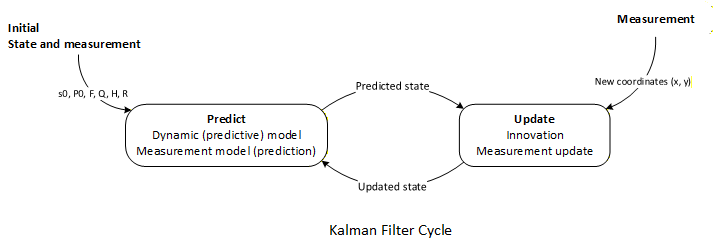

## Dataset — Microsoft GeoLife GPS Trajectories

### Source and collection

The **GeoLife** dataset was collected by Microsoft Research Asia between April 2007 and August 2012 [[Zheng et al., 2009]](https://www.microsoft.com/en-us/download/details.aspx?id=52367). 182 users recorded their outdoor movements in and around Beijing, China, using GPS loggers and GPS-enabled phones over a period of more than five years.

> **Download:** https://www.microsoft.com/en-us/download/details.aspx?id=52367

> [User Guide-1.3 and Microsoft Research License Agreement](data/raw_data_trajectories/Geolife%20Trajectories%201.3/Geolife%20Trajectories%201.3/User%20Guide-1.3.pdf)


The full dataset contains **17,621 trajectories**, covering a total distance of approximately 1.2 million kilometres and over 48,000 hours of movement. **91% of trajectories** are recorded at high density — one point every **1–5 seconds** or every 5–10 metres.

### Files used in this analysis

The dataset is organised by user:
```
Data/
├── 010/
│   ├── labels.txt          ← transport mode per time interval
│   └── Trajectory/         ← 161 .plt files
│       └── ...
├── 020/
├── labels.txt          ← transport mode per time interval
│   └── Trajectory/         ← 151 .plt files
│       └── ...
└── ── 021/
├── labels.txt          ← transport mode per time interval
    └── Trajectory/         ← 8 .plt files
        └── ...
```

Total: **320 trajectory files** across 3 users.

---

### File format

Each `.plt` file is a plain-text GPS log. The first 6 lines are a fixed header and are skipped. From line 7 onward:

| Column | Field | Unit |
|--------|-------|------|
| 0 | Latitude | degrees WGS-84 |
| 1 | Longitude | degrees WGS-84 |
| 2 | Unused | — |
| 3 | Altitude | feet |
| 4 | Days since 1899-12-30 | float |
| 5 | Date | YYYY-MM-DD |
| 6 | Time | HH:MM:SS |

Transport mode labels are stored in a separate `labels.txt` per user:
```
Start Time          End Time            Transportation Mode
2008/06/26 11:11:07 2008/06/26 11:31:08 taxi
2008/06/26 11:31:08 2008/06/26 12:03:00 taxi
2008/06/28 08:55:00 2008/06/28 09:14:00 car
...
```

---

## Theory and Motion Model

### System model and initialization

#### Initial conditions

To run the Kalman filter, we must specify an initial state estimate and its
error covariance:
$$
s_{0|0} \in \mathbb{R}^6, \qquad P_{0|0} \in \mathbb{R}^{6\times 6}.
$$

In our application, we initialise the state from the first measurement and
simple assumptions about velocity and acceleration, for example:
$$
s_{0|0} =
\begin{bmatrix}
x_0^{\text{meas}} \\
y_0^{\text{meas}} \\
0 \\
0 \\
0 \\
0
\end{bmatrix}.
$$

The matrix $P_{0|0}$ encodes how uncertain we are about this initial guess.
We choose it to be diagonal,
$
P_{0|0} = \operatorname{diag}
\bigl(\sigma_{x,0}^2,\,
      \sigma_{y,0}^2,\,
      \sigma_{v_x,0}^2,\,
      \sigma_{v_y,0}^2,\,
      \sigma_{a_x,0}^2,\,
      \sigma_{a_y,0}^2\bigr),
$
with relatively small variances for position (close to the sensor accuracy)
and large variances for velocity and acceleration, reflecting our lack
of prior knowledge about them.

The idea is:
* $s_{0∣0}$ is the initial estimate of the state (position from the sensor, velocities/accelerations often set to 0).
* $P_{0∣0}$ expresses how uncertain we are about this estimate; large diagonal entries mean “very uncertain”, which allows the filter to adapt quickly to the real data.

$P$ is the matrix that describes how uncertain we are about our state estimate.

We have a true (unknown) state $s_k$ and an estimated state $s_{k|k}$.
The estimation error is
$$
e_k = s_k - s_{k|k}.
$$

The matrix $P_{k|k}$ is the covariance of this error:
$$
P_{k|k} = \mathbb{E}[e_k e_k^T].
$$

In our 6-dimensional model,
$$
P_{k|k} \in \mathbb{R}^{6\times 6}.
$$

Intuitively:
- a large $P$ means the filter believes the estimate $s_{k|k}$ is unreliable
  (high uncertainty);
- a small $P$ means the filter is confident in $s_{k|k}$.

During the algorithm:
- in the prediction step, $P$ grows because we add uncertainty from the model
  and the process noise $Q$;
- in the measurement update step, $P$ shrinks because the new measurement
  reduces our uncertainty.

If $P_0$ is "wrong", the filter still works, but its behavior in the first
few steps changes.

If $P_0$ is too small (you think you know the initial state very well):
the filter will trust the initial estimate strongly and will mostly ignore
the first measurements, adapting more slowly to the true trajectory.

If $P_0$ is too large (you say "I know almost nothing"):
the filter will trust the first measurements very aggressively, adapting
quickly, but it may react noisily or be somewhat unstable in the initial
steps.

If the structure of $P_0$ is strange (for example, large covariances between
unrelated components):
the initial corrections of velocity and acceleration can be unintuitive.
However, for a linear Kalman filter, the effect of an incorrect $P_0$
usually disappears after enough measurements, as long as the model and
the noise covariances $Q$ and $R$ are reasonable.



#### State vector and transition matrix


At each moment $k$, we describe the object with a vector:  
$$ s_k = \begin{bmatrix} x_k \\ y_k \\ v_{x,k} \\ v_{y,k} \\ a_{x,k} \\ a_{y,k} \end{bmatrix},\, s_k \in \mathbb{R}^6 $$

Idea: if we know position, velocity, and acceleration now, we can predict where it will be after a small $ \Delta{t} $.

Measurement (only position from cameras/sensors):  

$$
z_k = \begin{bmatrix}
x_k^{meas} \\
y_k^{meas} \\
\end{bmatrix} , z_k \in \mathbb{R}^2
$$

In this model, we assume that the sensors measure only the position, and the speeds and accelerations are evaluated by the filter, assuming an approximate constant acceleration between measurements.

I use classical kinematics in constant acceleration for a small step $\ dt$:  
$$ x_{k+1} = x_k + v_{x,k}\,dt + \frac{1}{2} a_{x,k}\,dt^2 $$
$$ v_{x,k+1} = v_{x,k} + a_{x,k}\,dt $$
, analogous to $y$  
$$ y_{k+1} = y_k + v_{y,k}\,dt + \frac{1}{2} a_{y,k}\,dt^2 $$
$$ v_{y,k+1} = v_{y,k} + a_{y,k}\,dt $$
Acceleration does not change ("constant acceleration" model).
This gives us the transition matrix $F$:
$$ F = \begin{bmatrix}
1 & 0 & dt & 0 & \frac{1}{2}dt^2 & 0 \\
0 & 1 & 0 & dt & 0 & \frac{1}{2}dt^2 \\
0 & 0 & 1 & 0 & dt & 0 \\ 
0 & 0 & 0 & 1 & 0 & dt \\ 
0 & 0 & 0 & 0 & 1 & 0  \\ 
0 & 0 & 0 &  0 & 0 & 1 \\ 
\end{bmatrix}
$$ 

We use the transition matrix to describe how the state changes from step to step:
$$
s_{k+1} = F \, s_k + w_k
$$
where $w_k$ is a random vector that models unknown influences in the dynamics of the model.

**Note:** In the general discrete-time Kalman filter, the state evolution is written as

$$
s_k = F_k s_{k-1} + B_k u_k + w_k,
$$


In [3]:
def F_const_acc_2d(dt):
    """
    State transition matrix F for 2D constant-acceleration model
    with state [x, y, vx, vy, ax, ay]^T.
    
    Parameters
    ----------
    dt : float
        Time step in seconds.

    Returns
    -------
    F : (6, 6) ndarray
        State transition matrix.
    """
    dt2 = 0.5 * dt**2

    F = np.array([
        [1.0, 0.0, dt,  0.0, dt2, 0.0],
        [0.0, 1.0, 0.0, dt,  0.0, dt2],
        [0.0, 0.0, 1.0, 0.0, dt,  0.0],
        [0.0, 0.0, 0.0, 1.0, 0.0, dt ],
        [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
    ])

    return F

#### Dynamic model

In reality, the motion is affected by unpredictable "kicks" – process noise (for example, extra acceleration during the turn). This noise is
* different at each time step,
* but assumed constant within one sampling interval $\Delta{t}$.
* The matrix $Q$ describes how strong these random kicks are and how they propagate into position, velocity, and acceleration along the X and Y axes.
* We assume that the process noise in X and Y is uncorrelated, so Q splits into two identical 3×3 blocks: one for $\left(x, v_x, a_x \right)$ and one for $\left(y, v_y, a_y \right)$. The cross terms between X and Y are zero.
* The parameter $\sigma_a^2$ is the "acceleration variance" – a single number that scales the whole Q:
   * small $\sigma_a^2$ - we believe the constant‑acceleration model is almost exact;
   * large $\sigma_a^2$ - we allow more erratic motion and let the trajectory bend more to fit the measurements.

The process noise $w_k$ has zero mean and covariance 
$\mathbb{E}[w_k] = 0, \quad \mathbb{E}[w_k w_k^T] = Q.$

If the dynamic model doesn’t include a control input, we can project the random variance $\sigma_a^2$ on this dynamic model using the state transition matrix.
The process noise matrix is $  Q = FQ_aF^T $, $ Q_a = \sigma_Q^2\,diag(0,0,0,0,1,1)$, where $\sigma_a^2$ sets how uncertain we are in the equation of motion, and $Q$ is the covariance matrix of the process noise $w_k$. **(from "Kalman Filter from the Ground Up" [KalmanFilterNet])**

In our implementation we model the process noise through an auxiliary
covariance matrix $Q_a$, which is projected into the full state space as $Q = F Q_a F^T$ .

For the two–dimensional constant–acceleration state vector $s_k = [x_k , y_k , v_{x,k} , v_{y,k}, a_{x,k}, a_{y,k}]^T$, we choose $Q_a = \sigma_a^2 \, \operatorname{diag}(0, 0, 0, 0, 1, 1)$.

This choice reflects the physical assumption that the main source of model uncertainty is the random acceleration of the vehicle, while position and velocity do not receive independent process–noise inputs. In other words, only the acceleration components $a_x$ and $a_y$ are directly excited by process noise, and the induced uncertainty in position and velocity arises through the state–transition matrix $F$. The scalar parameter $\sigma_a^2$ represents the
variance of the unknown accelerations and therefore controls how aggressively the filter allows the trajectory to deviate from the nominal constant–acceleration model.

An often–used but less structured alternative is to take $Q_a = \sigma_a^2 I_n$ where $I_n$ is the identity matrix. This isotropic choice injects process noise with the same variance into all state components simultaneously. While it can be convenient when no detailed motion model is available, it does not distinguish between physically meaningful sources of uncertainty and makes the interpretation of $\sigma_a^2$ less clear. For the vehicle–tracking scenario considered here, the structured form $Q_a = \sigma_a^2 \, \operatorname{diag}(0, 0, 0, 0, 1, 1)$ is therefore more appropriate, as it explicitly encodes that process noise acts only on the acceleration states.


Intuition:  
- larger Q → we trust the model less, we let the trajectory "adjust" to the data.

In [4]:
def process_noise_Q(F, sigma_a):
    """
    Build process noise covariance Q from state transition F
    and scalar acceleration std sigma_Q, assuming noise only
    in the last state component.
    Parameters
    ----------
    F : (n, n) ndarray
        State transition matrix.
    sigma_Q : float
        Standard deviation of the acceleration noise.
    Returns
    -------
    Q : (n, n) ndarray
        Process noise covariance matrix F Q_a F^T.
    """
    n = F.shape[0]
    
    # alternatively
    # Q_a = sigma_a^2 * np.eye(n)
    
    Qa = (sigma_a**2) * np.diag([0, 0, 0, 0, 1, 1])
  
    Q = F @ Qa @ F.T
    return Q


#### Measurement model

In our experiment, cameras/detectors only give position without directly measuring velocity and acceleration.
The measurement matrix 𝐻 specifies which components of the state vector are directly observed by the sensors. In our case, the sensors provide only the position, $(𝑥_𝑘,𝑦_𝑘)$, while velocities and accelerations are not measured.

Therefore, from this we get:
$$
H = \begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 \\
\end{bmatrix}
$$
Thus, we will get the 'correct' measurement as $$ z_k = H \, s_k + m_k$$, where $m_k$ is an unknown noise vector in the measurement (measurement noise) at time k, following the formulation in the RWTH lecture notes and TheKalmanFilter.com [RWTH-CV2, TheKalmanFilter].

The measurement noise $m_k$ has zero mean and covariance $R$:
$$\mathbb{E}[m_k] = 0, \quad \mathbb{E}[m_k m_k^T] = R.$$

Conditionally, the sensor supplier assures us that the maximum standard deviation is $ \sigma_R $, then
$$ 
R = \begin{bmatrix}
\sigma_R^2 & 0 \\
0 & \sigma_R^2 
\end{bmatrix}
$$
Intuition:  
- greater R → less trust in measurements;  

In [5]:
def H_pos_only_2d():
    """
    Measurement matrix H for 2D position sensor.
    State: [x, y, vx, vy, ax, ay]^T
    Measurement: [x, y]^T
    """
    H = np.array([
        [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    ])
    return H
    
def R_pos_only_2d(sigma_pos):
    """
    Measurement noise covariance R for 2D position sensor.
    
    Parameters
    ----------
    sigma_pos : float
        1-sigma position error [m], assuming same for x and y.
    
    Returns
    -------
    R : (2, 2) ndarray
        Measurement noise covariance matrix.
    """
    var = sigma_pos**2
    R = np.array([
        [var, 0.0],
        [0.0, var],
    ])
    return R


### Predict step

In the general discrete-time Kalman filter, the state evolution is
written as
$$
s_k = F_k s_{k-1} + B_k u_k + w_k,
$$
where $u_k$ is a known control input (for example, motor commands or steering actions) and $B_k$ is the corresponding control-input matrix. This term describes how deliberate control actions modify the state in addition to the natural dynamics encoded in $F_k$.

In our tracking problem, we perform passive observation of moving objects in 2D: 
* We do not command the objects;
* We only measure their positions. There is no known control signal $u_k$ that could be included in the model.
* Any unknown manoeuvres are treated as part of the process noise $w_k$, not as deterministic control inputs.

For this reason, we set $B_k u_k = 0$ and use the simplified state equation $s_k = F s_{k-1} + w_k$, which is the standard form adopted in many tracking-oriented introductions to the Kalman filter.

Once the dynamic model has been defined, the Kalman filter uses it to
predict how the state evolves between two consecutive measurements.
Given the current best estimate $s_{k|k}$ and its covariance
$P_{k|k}$ at time $k$, the prediction (also called time update or
prior estimate) for the next time step $k+1$ is obtained by
propagating both the state and its uncertainty through the motion model:
$$
s_{k+1|k} = F\,s_{k|k},
$$
$$
P_{k+1|k} = F\,P_{k|k}F^\top + Q.
$$

The first equation applies the state transition matrix F to predict where the object would be at time k+1 if the motion followed the assumed constant-acceleration model exactly. The second equation updates the covariance matrix to reflect how uncertainty grows during the prediction step: the linear transformation by F redistributes the existing uncertainty in $P_{k|k}$, while the process noise covariance $Q$ accounts for unmodelled accelerations, manoeuvres and approximations in the dynamic model. Together, these two equations produce the prior estimate $(s_{k+1|k}, P_{k+1|k})$, which will later be corrected in the update step when a new measurement becomes available.

### Update step

#### Innovation

The sensor measures position (2D), so the measurement model is
$$
z_{k+1} = H\,s_{k+1} + m_{k+1},
$$
where $m_{k+1}$ is the measurement noise.
$s_{k+1}$ is the true state of the object at time $k+1$, the value that the real world has but we never observe directly.

$s_{k+1|k}$ is our predicted estimate of that state, computed by the filter using only the model and all information up to time $k$:
$$
s_{k+1|k} = F\,s_{k|k}.
$$

Then we compare the actual measurement $z_{k+1}$ with the corresponding predicted measurement
$$
\hat{z}_{k+1|k} = H\,s_{k+1|k}.
$$

and the innovation (surprise) 
$$
e_{k+1} = z_{k+1} - \hat{z}_{k+1|k}
$$
tells us how surprising the new data is relative to the model.


#### Measurement update

Intuitively, the Kalman filter averages two things at every step – what the model has predicted and what the sensor has measured. Instead of blindly trusting either one, it takes a weighted average: if the measurements are very noisy, it trusts the model more; if the model is uncertain, it trusts the measurements more.

The following formulas tell how we correct the predicted state with the new measurement.
1) Kalman gain

$$
K_{k+1} = P_{k+1|k} H^T \bigl(H P_{k+1|k} H^T + R\bigr)^{-1}.
$$

Here:
- $\left( P_{k+1|k} \right)$ is the uncertainty of the predicted state $s_{k+1|k}$.
- $\left( H P_{k+1|k} H^T + R \right)$ is the total uncertainty in the measurement space
  (model uncertainty projected by $H$ plus sensor noise $R$).
- $K_{k+1}$ tells us how much we should trust the new measurement
  relative to our model prediction. A larger $R$ gives a smaller $K_{k+1}$,
  meaning we trust the sensor less.


The Kalman gain $K_k$ is exactly this “trust coefficient” – it determines how strongly the new measurement should pull the current prediction, so that the final estimate has the smallest possible uncertainty.

2) State update

The innovation (residual) is
$$
e_{k+1} = z_{k+1} - \hat{z}_{k+1|k}
         = z_{k+1} - H s_{k+1|k}.
$$

The updated state estimate is
$$
s_{k+1|k+1} = s_{k+1|k} + K_{k+1} e_{k+1}.
$$

Interpretation in our context:
- $s_{k+1|k}$ is the predicted state from the constant-acceleration model.
- $e_{k+1}$ measures how different the actual measurement is from what
  the model expected.
- The term $K_{k+1} e_{k+1}$ is the correction we add to the prediction;
  it adjusts position, but also velocity and acceleration through $K_{k+1}$.


3) Covariance update

$$
P_{k+1|k+1} = \left(I_6 - K_{k+1} H \right)\, P_{k+1|k}.
$$
in line with the derivations in Welch & Bishop and Bzarg’s pictorial explanation [Welch & Bishop, Bzarg].   

Here:
- $K_{k+1} H$ represents how much of the prediction error is corrected
  using the measurement.
- The updated covariance $P_{k+1|k+1}$ is smaller (or equal) than
  $P_{k+1|k}$, meaning we are more certain about the state after
  incorporating the new measurement, especially in the observed
  position components and indirectly in velocities and accelerations.


In the notation commonly used in the RWTH Computer Vision 2 notes and Welch & Bishop’s introduction [RWTH-CV2, Welch & Bishop].

## Implementation

### Data Loading

Each `.plt` file is read with `pandas.read_csv()`, skipping the 6-line header. Columns `date` and `time` are combined into a single `ts` (timestamp) column. Only `lat`, `lon` and `ts` are retained — altitude and the unused field are dropped.

The example below shows a single file from user 010: **1,116 points** recorded over **44 minutes** on 2007-08-04.

In [6]:
def read_plt(path):
    """
    Read a GeoLife .plt file into a DataFrame.

    The first 6 lines are a fixed header and are skipped.

    Parameters
    ----------
    path : str
        Path to the .plt file.

    Returns
    -------
    df : DataFrame
        Columns: lat, lon, ts (timestamp).
    """
    df = pd.read_csv(
        path,
        skiprows=6,
        header=None,
        names=['lat', 'lon', '_', 'alt', 'days', 'date', 'time']
    )
    df['ts'] = pd.to_datetime(df['date'] + ' ' + df['time'])
    return df[['lat', 'lon', 'ts']].reset_index(drop=True)

In [7]:
# Quick look at a single .plt file
sample_path = 'data/raw_data_trajectories/geolife_1.3/geolife_trajectories/data/010/Trajectory/20070804033032.plt'

df_sample = read_plt(sample_path)

print(f"Points:    {len(df_sample)}")
print(f"From:      {df_sample['ts'].min()}")
print(f"To:        {df_sample['ts'].max()}")
print(f"Duration:  {df_sample['ts'].max() - df_sample['ts'].min()}")
print()
df_sample.head()

Points:    1116
From:      2007-08-04 03:30:32
To:        2007-08-04 04:14:46
Duration:  0 days 00:44:14



,lat,lon,ts
0,39.921712,116.472343,2007-08-04 03:30:32
1,39.921705,116.472343,2007-08-04 03:30:33
2,39.921695,116.472345,2007-08-04 03:30:34
3,39.921683,116.472342,2007-08-04 03:30:35
4,39.921672,116.472342,2007-08-04 03:30:36


### Label Matching

Each user's `labels.txt` maps time intervals to transport modes.
`read_labels()` parses the file into a DataFrame with `start`, `end` and `mode` columns.

`compute_dt()` computes the time difference between consecutive GPS points in seconds
and returns a boolean mask `valid` — `True` for steps within `max_dt` seconds.
This is used later to detect GPS signal loss.

`match_segments()` iterates over all labelled intervals, extracts the GPS points
that fall within each interval, and keeps only segments with at least `min_points` points.

In [8]:
def read_labels(path):
    """
    Read a GeoLife labels.txt file.

    Parameters
    ----------
    path : str
        Path to labels.txt

    Returns
    -------
    df : DataFrame
        Columns: start, end, mode
    """
    df = pd.read_csv(path, sep='\t')
    df.columns = ['start', 'end', 'mode']
    df['start'] = pd.to_datetime(df['start'])
    df['end']   = pd.to_datetime(df['end'])
    return df

def compute_dt(df, max_dt=30.0):
    dt = np.diff(df['ts'].values).astype('timedelta64[s]').astype(float)
    valid = dt <= max_dt          # маска на валидни стъпки
    return dt, valid


def match_segments(traj, labels, modes=('car', 'taxi'), min_points=30):
    """
    Extract trajectory segments that fall within labelled time intervals.

    Parameters
    ----------
    traj       : DataFrame   output of read_plt()
    labels     : DataFrame   output of read_labels()
    modes      : tuple       transport modes to keep
    min_points : int         minimum points per segment

    Returns
    -------
    segments : list of dict
        Each dict has keys: mode, df (subset of traj)
    """
    segments = []
    for _, row in labels[labels['mode'].isin(modes)].iterrows():
        mask = (traj['ts'] >= row['start']) & (traj['ts'] <= row['end'])
        seg  = traj[mask].reset_index(drop=True)
        if len(seg) >= min_points:
            segments.append({'mode': row['mode'], 'df': seg})
    return segments

In [9]:
labels_path = 'data/raw_data_trajectories/geolife_1.3/geolife_trajectories/data/010/labels.txt'
labels      = read_labels(labels_path)

print(labels['mode'].value_counts())

mode
walk        153
train       100
taxi         96
subway       47
bus          35
airplane      2
car           1
Name: count, dtype: int64


### Segment Loading and Outlier Filtering

The raw GPS signal contains two types of variation:

1. **Real movement** — the vehicle actually changing position between fixes.
2. **Measurement noise** — random positional error from the GPS receiver, typically **4–10 metres** for consumer-grade devices.

These two are mixed together in the raw signal and cannot be separated by simply looking at a single point. The Kalman filter separates them by maintaining a **motion model** — it predicts where the vehicle *should* be based on its previous state, and then blends that prediction with the noisy GPS fix using two key parameters:
- **σ_r** (measurement noise) — how much we trust the GPS reading. Set from the step size distribution: σ ≈ 7.5 m.
- **σ_q** (process noise) — how much we allow the motion model to deviate. Reflects real acceleration — how aggressively the vehicle can change speed or direction between fixes.

The step size distribution (right panel) gives us a direct estimate of σ_r before we run a single line of Kalman code.

The GeoLife dataset stores positions as WGS-84 latitude/longitude degrees.
The Kalman filter works in Cartesian space (metres) — distances, velocities and accelerations are physically meaningful only in a metric coordinate system.

`to_xy()` projects each GPS fix onto a local flat-earth plane using the
**equirectangular approximation**:

$$x = R \cdot \Delta\lambda \cdot \cos(\phi_0)$$
$$y = R \cdot \Delta\phi$$

where $\phi_0$ is the latitude of the first point (origin), $\Delta\phi$ and $\Delta\lambda$ are the differences in latitude and longitude in radians, and $R = 6{,}371{,}000$ m is the Earth's mean radius.

The approximation is accurate to within ~0.1% for trajectories shorter than 100 km — well within the range of urban car and taxi trips.

Source: [Movable Type Scripts — Lat/Lon calculations](https://www.movable-type.co.uk/scripts/latlong.html)

In [10]:
def to_xy(df):
    """
    Convert lat/lon coordinates to local Cartesian (metres).

    Uses the first point as the origin. The approximation is
    valid for short trajectories (< ~100 km).

    Conversion factors:
        1 degree latitude  ≈ 111,320 m  (constant)
        1 degree longitude ≈ 111,320 * cos(lat) m  (varies with latitude)

    Source: https://en.wikipedia.org/wiki/Geographic_coordinate_system#Length_of_a_degree
    Source: https://www.movable-type.co.uk/scripts/latlong.html

    Parameters
    ----------
    df : DataFrame
        Output of read_plt() or a segment slice of it.
        Must contain columns: lat, lon.

    Returns
    -------
    x : ndarray   east-west displacement in metres
    y : ndarray   north-south displacement in metres
    """
    lat0 = df['lat'].iloc[0]
    lon0 = df['lon'].iloc[0]
    
    # Equirectangular approximation
    # Source: https://www.movable-type.co.uk/scripts/latlong.html
    R = 6_371_000  # Earth's radius in metres
    x = R * np.radians(df['lon'] - lon0) * np.cos(np.radians(lat0))
    y = R * np.radians(df['lat'] - lat0)

    return x.values, y.values

In [11]:
def load_all_segments(trajectory_dir, labels_path, modes=('car', 'taxi'), min_points=30):
    labels    = read_labels(labels_path)
    plt_files = glob.glob(os.path.join(trajectory_dir, '*.plt'))

    segments = []
    for plt_path in plt_files:
        traj = read_plt(plt_path)
        segs = match_segments(traj, labels, modes, min_points)
        for s in segs:
            s['file'] = os.path.basename(plt_path) 
        segments.extend(segs)
       
    return segments

def has_outlier(seg, max_dt=10.0):
    dt, valid = compute_dt(seg['df'])
    return not valid.all()

In [12]:
dir_trj = "data/raw_data_trajectories/geolife_1.3/geolife_trajectories/data/"
users = [
    {
        "trajectory_dir": f"{dir_trj}/010/Trajectory/",
        "labels_path":    f"{dir_trj}/010/labels.txt"
    },
    {
        "trajectory_dir": f"{dir_trj}/020/Trajectory/",
        "labels_path":    f"{dir_trj}/020/labels.txt"
    },
    {
        "trajectory_dir": f"{dir_trj}/021/Trajectory/",
        "labels_path":    f"{dir_trj}/021/labels.txt"
    },
]

all_segments = []
for user in users:
    segs = load_all_segments(
        trajectory_dir = user['trajectory_dir'],
        labels_path    = user['labels_path']
    )
    all_segments.extend(segs)

print(f"Total segments: {len(all_segments)}")
print(f"Car:  {sum(1 for s in all_segments if s['mode'] == 'car')}")
print(f"Taxi: {sum(1 for s in all_segments if s['mode'] == 'taxi')}")

print(f"Total segments: {len(all_segments)}")

Total segments: 103
Car:  11
Taxi: 92
Total segments: 103


In [13]:
for s in all_segments:
    if s['mode'] == 'car':
        x, y = to_xy(s['df'])
        steps = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
        print(f"{s['file']}  n={len(s['df'])}  max_step={steps.max():.1f}m")

20080927114213.plt  n=2372  max_step=106.9m
20110911000506.plt  n=4213  max_step=2782.3m
20070429222711.plt  n=208  max_step=50423.3m
20070429222711.plt  n=78  max_step=23446.9m
20070429222711.plt  n=253  max_step=64527.9m
20070501010311.plt  n=53  max_step=14533.1m
20070501010311.plt  n=75  max_step=25967.4m
20070501010311.plt  n=118  max_step=2453.7m
20070502001318.plt  n=85  max_step=82475.0m
20070502013107.plt  n=98  max_step=1167.4m
20070502013107.plt  n=44  max_step=1183.1m


In [14]:
def has_gps_jump(seg, max_step=500):
    x, y  = to_xy(seg['df'])
    steps = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
    return steps.max() > max_step

all_segments = [s for s in all_segments if not has_gps_jump(s)]

print(f"Total segments: {len(all_segments)}")
print(f"Car:  {sum(1 for s in all_segments if s['mode'] == 'car')}")
print(f"Taxi: {sum(1 for s in all_segments if s['mode'] == 'taxi')}")

Total segments: 91
Car:  1
Taxi: 90


In [15]:
def plot_raw_trajectory(seg, title=None):
    """
    Plot a single raw GPS trajectory segment.
    Left panel  : 2D path in local Cartesian coordinates (km).
    Right panel : distribution of step sizes between consecutive GPS fixes.
    """
    x, y  = to_xy(seg['df'])
    steps = np.sqrt(np.diff(x)**2 + np.diff(y)**2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: trajectory ---
    axes[0].plot(x/1000, y/1000, 'o-', color='crimson',
                 ms=2, lw=1, alpha=0.7)
    axes[0].set_xlabel('X (km)')
    axes[0].set_ylabel('Y (km)')
    axes[0].set_title(f"Raw GPS — {seg['mode']} (n={len(x)})")
    axes[0].grid(True)

    # --- Right: step size distribution ---
    axes[1].hist(steps, bins=30, color='crimson', alpha=0.8)
    axes[1].axvline(steps.mean(), color='white', lw=2, ls='--',
                    label=f'mean={steps.mean():.1f} m')
    axes[1].set_xlabel('Step size (m)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f"Step distribution  σ={steps.std():.2f} m")
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(title or seg['file'])
    plt.tight_layout()
    plt.show()

Each plot shows two panels:

- **Left** — the 2D trajectory in local Cartesian coordinates. The origin (0, 0) is the first GPS fix of the segment. Jitter on straight sections is visible GPS noise.
- **Right** — the distribution of step sizes between consecutive fixes (1-second intervals).

The dashed white line marks the mean step size; σ is the standard deviation — our empirical estimate of GPS positional noise.

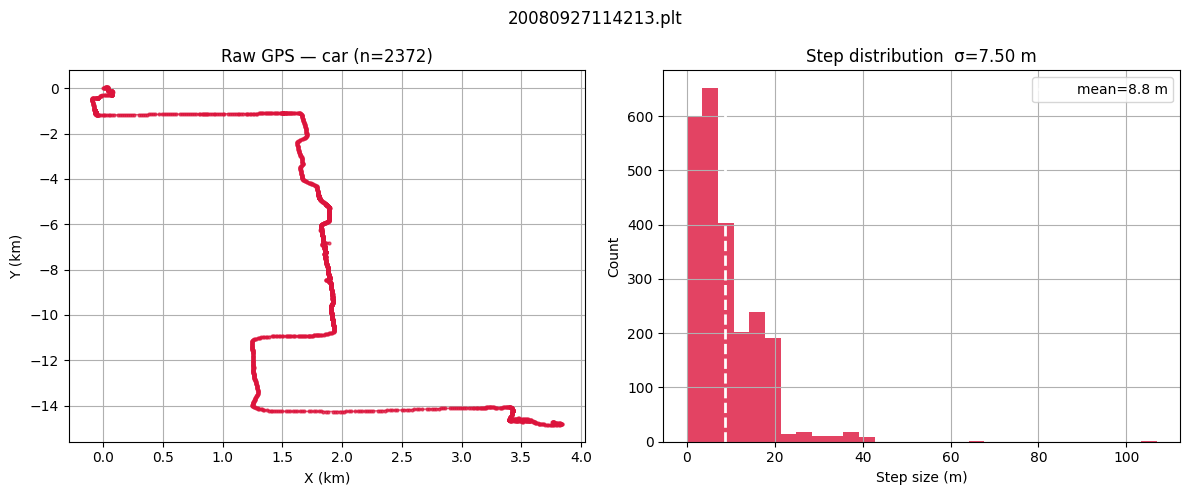

In [16]:
# The Car segment
car_seg = next(s for s in all_segments if s['mode'] == 'car')
plot_raw_trajectory(car_seg)

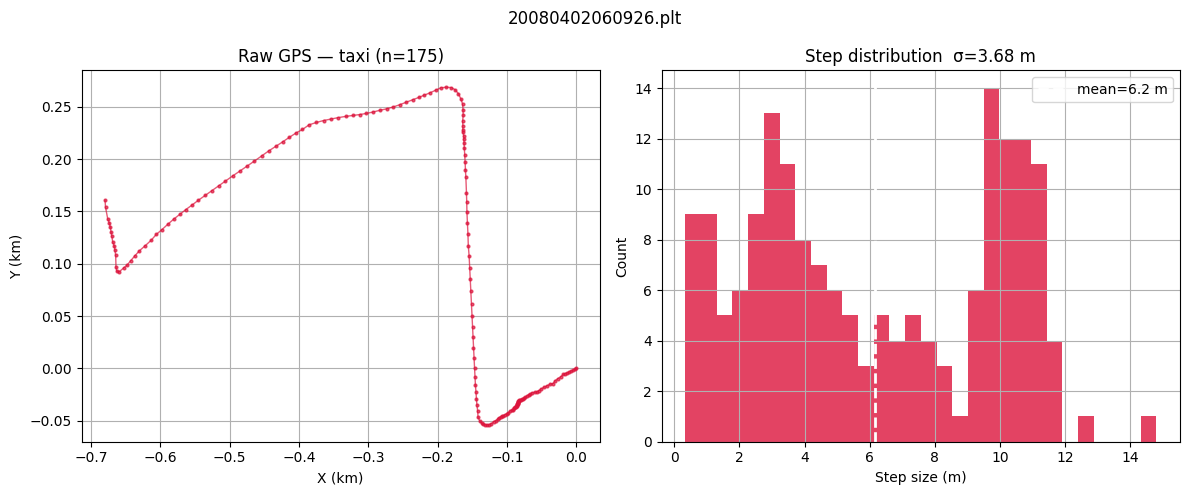

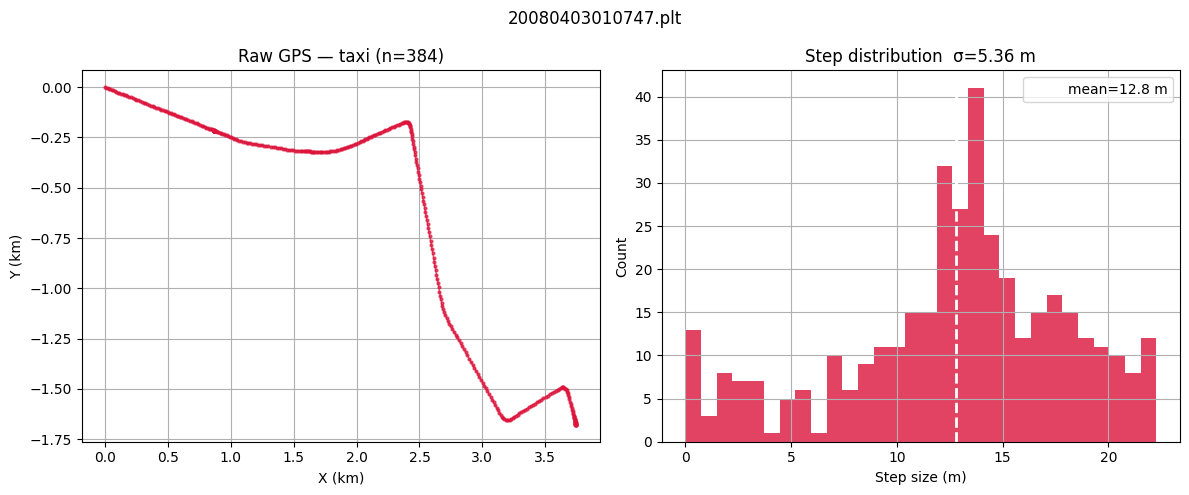

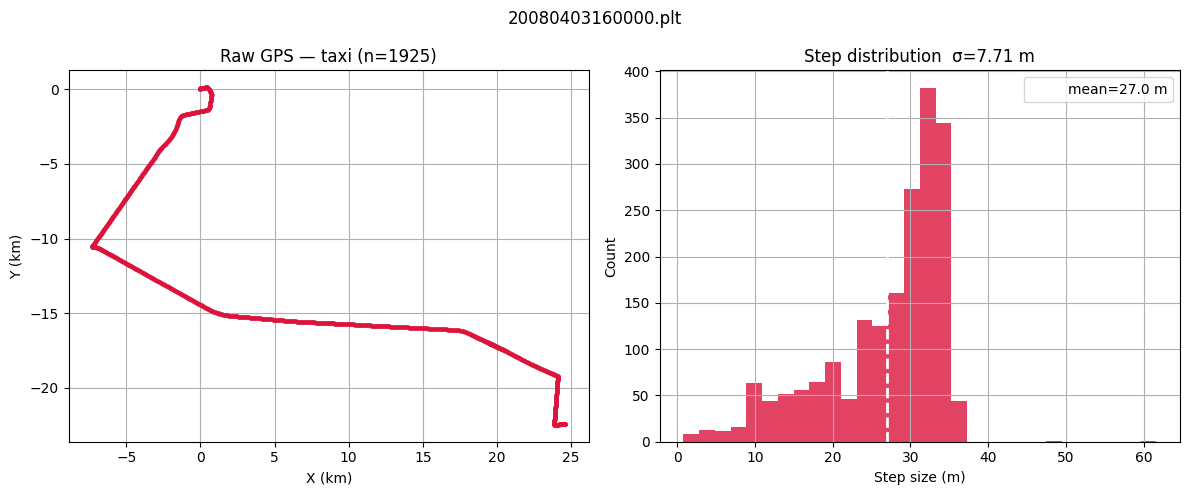

In [17]:
# 3 taxi segment
taxi_segs = [s for s in all_segments if s['mode'] == 'taxi'][:3]
for s in taxi_segs:
    plot_raw_trajectory(s)

> **TODO:** Extend analysis to all transport modes (walk, bike, bus, subway, train).
> Each mode has distinct motion characteristics and may benefit from different
> Kalman parameters (σ_r, σ_q).

### Raw Data Validation

Before applying the Kalman filter, we visually inspect two representative segments: the longest taxi trajectory and the only car segment.

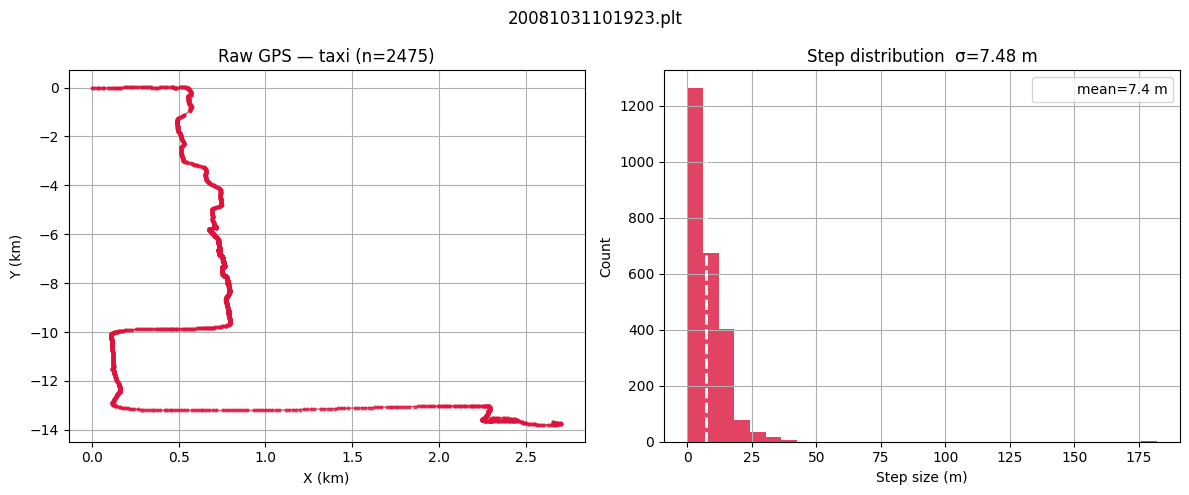

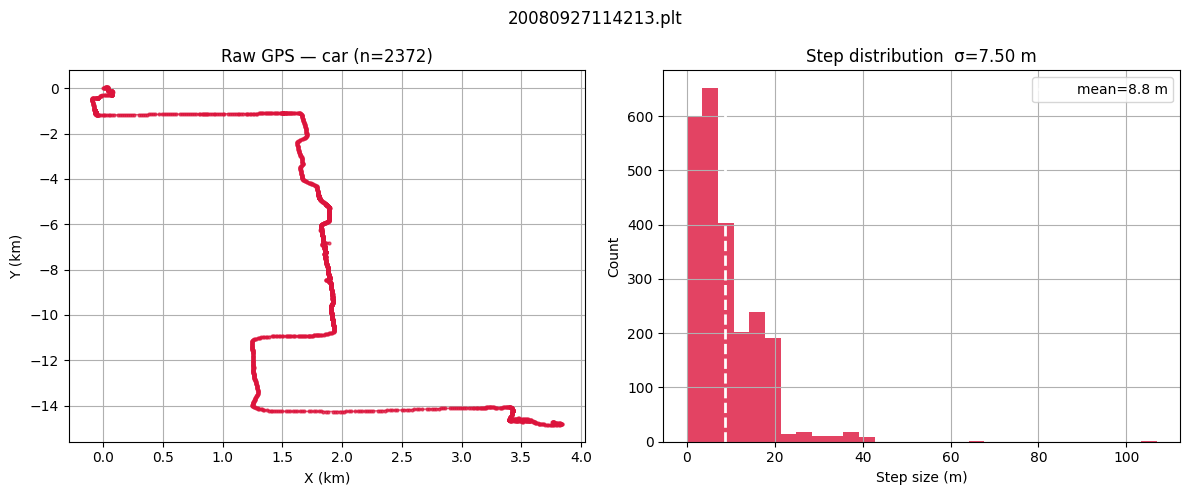

In [18]:
# Raw visualization — longest taxi segment
longest_taxi = max(
    (s for s in all_segments if s['mode'] == 'taxi'),
    key=lambda s: len(s['df'])
)
plot_raw_trajectory(longest_taxi)

# The only car segment
car_seg = next(s for s in all_segments if s['mode'] == 'car')
plot_raw_trajectory(car_seg)

Both car and taxi segments show a GPS positional noise of approximately **7.5 metres** (measured as the standard deviation of step sizes). This is consistent with consumer-grade GPS accuracy under urban conditions (Beijing, 2007–2008).

The trajectory plot reveals the characteristic jitter of consumer GPS — the path appears jagged even on straight road sections. This is exactly what the Kalman filter is designed to smooth.

## Realization 

### Class Kalman2D

### Class Kalman2D

File _src/kalman_tracker.py_ defines a generic 2D Kalman class _Kalman2D_, with a built-in logger for all key quantities.

**General idea:**

The Kalman2D class implements the standard linear Kalman filter for a state $s_k \in \mathbb{R}^n$ and a measurement $z_k \in \mathbb{R}^m$, with the following matrices:

- $F$ – state transition matrix
- $Q$ – process noise covariance
- $H$ – measurement matrix
- $R$ – measurement noise covariance
- $B$ – control input matrix (optional, default `None`)

Optionally, it accepts a `StateLogger`, which records at each step: states $s$, covariances $P$, gain $K$, measurements $z$, predicted measurements $\hat{z}$, and innovations $e$.

For variable time-step applications (e.g. GPS), `F_builder(dt)` and `Q_builder(dt)` can be supplied — the matrices are then rebuilt at each prediction step.

**Methods:**

_`__init__(self, F, Q, H, R, logger=None, F_builder=None, Q_builder=None, B=None)`_  
Stores matrices and optional logger. No logic, just configuration.

_`predict(self, s_k_k, P_k_k, dt=None, u=None)`_  
Implements the prediction step:
$$s_{k+1|k} = F s_{k|k} + B u_k \qquad P_{k+1|k} = F P_{k|k} F^\top + Q$$
If `dt` and `F_builder` are provided, $F$ and $Q$ are rebuilt for the current time step.  
Returns $(s_{k+1|k},\ P_{k+1|k})$.

_`update(self, s_k1_k, P_k1_k, z_k1)`_  
Combines innovation, Kalman gain, state update and covariance update in one call:
$$e = z_{k+1} - H s_{k+1|k} \qquad K = P_{k+1|k} H^\top S^{-1}$$
$$s_{k+1|k+1} = s_{k+1|k} + K e \qquad P_{k+1|k+1} = (I - KH)\, P_{k+1|k}$$
Logs $s, P, K, z, \hat{z}, e$ if a logger is attached.  
Returns $(s_{k+1|k+1},\ P_{k+1|k+1})$.

_`reset()`_  
Clears the logger history. Use between segments when reusing the same instance.

[Open kalman_tracker.py](src/kalman_tracker.py)

## Examples

In [19]:
def init_state_from_measurement(z0):
    x0, y0 = np.squeeze(z0)
    s_0_0 = np.array([[x0],
                      [y0],
                      [0.0],   # v_x
                      [0.0],   # v_y
                      [0.0],   # a_x
                      [0.0]])  # a_y
    return s_0_0

def init_covariance(R_meas):
    P = np.eye(6) * R_meas
    return P

In [20]:
def kf_step(kf_tracker, s_k_k, P_k_k, z_k1, dt=None, u=None):
    """
    A complete Kalman update:
    1) predict
    2) update
    """
    s_k1_k,  P_k1_k  = kf_tracker.predict(s_k_k, P_k_k, dt=dt, u=u)
    s_k1_k1, P_k1_k1 = kf_tracker.update(s_k1_k, P_k1_k, z_k1)

    return s_k1_k1, P_k1_k1

In [21]:
def extract_xy_from_history(points_hist):
    points_arr = points_hist.squeeze()
    x = points_arr[:, 0]
    y = points_arr[:, 1]

    return x, y

In [22]:
def extract_state_components(s_hist):
    arr = np.squeeze(s_hist)   # (N, 6)
    x  = arr[:, 0]
    y  = arr[:, 1]
    vx = arr[:, 2]
    vy = arr[:, 3]
    ax = arr[:, 4]
    ay = arr[:, 5]
    return x, y, vx, vy, ax, ay


In [23]:
def plot_trajectory(x_meas, y_meas,
                    x_est,  y_est,
                    x_true=None, y_true=None,
                    title='Online emulation: true, measured, and KF estimate'):
    plt.figure(figsize=(6, 6))

    # true trajectory (ако е подадена)
    if x_true is not None and y_true is not None:
        plt.plot(x_true, y_true, 'g-', label='true trajectory')

    # measurements
    plt.scatter(x_meas, y_meas, c='r', s=15, alpha=0.6, label='measurements')

    # KF estimate
    plt.plot(x_est, y_est, 'b-', label='KF estimate')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.title(title)
    plt.show()


**Example 1.**
The example simulates 2D motion, generates noisy measurements, and shows how a 6D Kalman filter reconstructs a smooth trajectory from them, using specific numeric parameters. The true motion is defined by the function true_position_poly(t), where $ x(t) = 0.5t + 0.01t^2 $, and $y(t) = 0.2 t - 0.005.t^2 + 0.00005t^3$.

Time is discretised with a step $dt = 1.0$, and the simulation runs for num_steps = 100. This produces a smooth, slightly curved trajectory in the plane over 100 time steps.

Measurements are generated by generate_measurement(t, amp_x=5.0, amp_y=5.0, freq_x=0.7, freq_y=0.7, phase_x0=0.0, phase_y0=0.0). For each time $t_k$, the code first computes the true position $\left( x_{true}, y_{true} \right) $, then adds sinusoidal noise with amplitude 5.0 in both axes and frequency 0.7 Hz. This yields measurements that oscillate around the true trajectory with relatively large, structured noise.

The Kalman filter uses a 6‑dimensional state $ s_k = [x, y, v_x, v_y, a_x, a_y]^T$, and and a constant‑acceleration transition matrix $F$ build from $dt = 1.0$.

The idea of the exercise is to demonstrate that at the beginning, the Kalman filter can deviate significantly from the true trajectory, because the initial state is set to zero and the initial covariance $P_0 = 5000 I$ encodes "I know almost nothing." In the first steps, it corrects aggressively towards the noisy measurements, so the estimate is far from the true path. As time progresses, through the repeated predict–update cycle and accumulated measurements, the filter gradually learns the actual motion, reduces its covariance, and the estimated trajectory converges towards the true one while smoothing out the sinusoidal measurement noise.

In [24]:
def generate_measurement(t, amp_x=5.0, amp_y=5.0, freq_x=0.7, freq_y=0.7, phase_x0=0.0, phase_y0=0.0):
    x_true, y_true = true_position_poly(t)

    z_x = x_true + amp_x * np.sin(2 * np.pi * freq_x * t + phase_x0)
    z_y = y_true + amp_y * np.sin(2 * np.pi * freq_y * t + phase_y0)

    return np.array([[z_x],
                     [z_y]])
    
def true_position_poly(t):
    a0, a1, a2 = 0.0, 0.5, 0.01
    x = a0 + a1 * t + a2 * t**2

    b0, b1, b2, b3 = 0.0, 0.2, -0.005, 0.00005
    y = b0 + b1 * t + b2 * t**2 + b3 * t**3
    return x, y
 

In [25]:
# sec.
dt = 1.0 
n = 6   # [x, y, vx, vy, ax, ay]
m = 2   # [x, y]

num_steps = 100
x_true_hist = np.zeros(num_steps)
y_true_hist = np.zeros(num_steps)

F = F_const_acc_2d(dt)
H = H_pos_only_2d()

# m/s^2
sigma_a = 0.01 
Q = process_noise_Q(F, sigma_a)

# The measurement error standard deviation: 3m 
sigma_r = 3
R =  R_pos_only_2d(sigma_r)

# -------------------------------------------------
# Online emulation using KF functions
# -------------------------------------------------

# initial true position
x_true_k = 0.0
y_true_k = 0.0
x_true_hist[0] = x_true_k
y_true_hist[0] = y_true_k

s_0_0 = init_state_from_measurement([0, 0])
P_0_0 = init_covariance(50000.0)

s_k_k = s_0_0
P_k_k = P_0_0


In [26]:
logger = StateLogger(["s", "z", "e", "K"])
kf_tracker = KalmanFilter(F, Q, H, R, logger)
for k in range(1, num_steps):
    t_k = k * dt
    # true trajectory
    x_true_k, y_true_k = true_position_poly(t_k)
    x_true_hist[k] = x_true_k
    y_true_hist[k] = y_true_k
    # measurement
    z_k1 = generate_measurement(t_k, sigma_r, 8.0, 8.0, 1.3, 1.7, 0)
    s_k_k, P_k_k = kf_step(
        kf_tracker, s_k_k, P_k_k, z_k1
    )

In [27]:
#Read the log
s_est, z_meas_hist = logger.get_stat(["s", "z"])

x_meas, y_meas = extract_xy_from_history(z_meas_hist)
kx_est, ky_est = extract_xy_from_history(s_est)

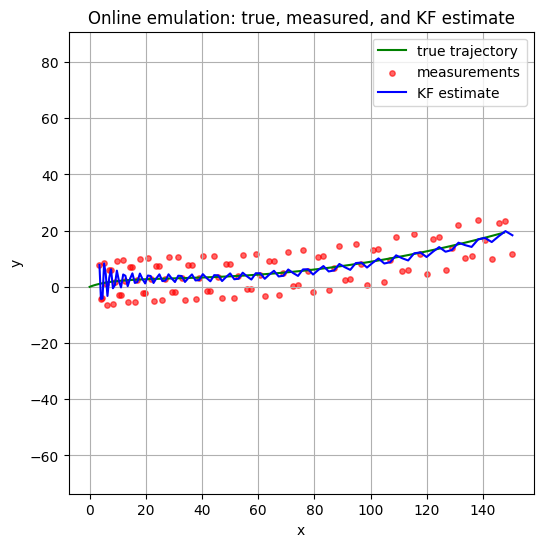

In [28]:
plot_trajectory(x_meas, y_meas,
                kx_est, ky_est,
                x_true_hist,y_true_hist)

**Example 2.** The following demo is directly taken from the book "Kalman Filter from the Ground Up" [KalmanFilterNet]. Let us assume a vehicle moving in a straight line in the X direction with a constant velocity. After travelling 400 meters, the vehicle turns left, with a turning radius of 300 meters. During the turning manoeuvre, the vehicle experiences acceleration due to the circular motion (angular acceleration). 

* The measurements period: $\Delta{t} = 1s$
* The random acceleration standard deviation: $\sigma_a = 0.2 \frac{m}{s^2}$  
* The measurement error standard deviation:  $\sigma_{x_m} = \sigma_{y_m} = 3m $

The data for the noisy position measurements of the vehicle are loaded from the text file _noisy_measurements.txt_, where each row contains the coordinates $\left( x_k, y_k \right) $
for the corresponding point in the trajectory.

[Open noisy_measurements.txt ](/data/noisy_measurements.txt)
    

In [54]:
data = np.loadtxt("data/noisy_measurements.txt", skiprows=1) 

data_x = data[:, 0]
data_y = data[:, 1]

In [55]:
dt = 1.0
n = 6
m = 2 

F_2 = F_const_acc_2d(dt)
H_2 = H_pos_only_2d()

# The random acceleration standard deviation: sigma_a = 0.2 m
sigma_a = 0.2
Q_2 = process_noise_Q(F_2, sigma_a)

# The measurement error standard deviation: σxm = σym = 3m
sigma_r = 3 
R_2 =  R_pos_only_2d(sigma_r)

# -------------------------------------------------
# Online emulation zero
# -------------------------------------------------

# We don’t know the vehicle location; we set the initial position, velocity, and acceleration to 0.
s_0_0 = init_state_from_measurement([0,0])

# Since our initial state vector is a guess, we set a very high estimate of uncertainty. The
# high estimate uncertainty results in a high Kalman Gain by giving a high weight to the
# measurement.
P_0_0 = init_covariance(500.0)

In [56]:
s_k_k = s_0_0
P_k_k = P_0_0


logger = logger = StateLogger(["s","z"])
kf_tracker = KalmanFilter(F_2, Q_2, H_2, R_2, logger)
for k in range(0, len(data)):
    t_k = k * dt
    z_k1 = data[k].reshape(2, 1)
    s_k_k, P_k_k = kf_step(
        kf_tracker, s_k_k, P_k_k, z_k1
    )

In [57]:
#Read the log
s_est, z_meas_hist = logger.get_stat(["s", "z"])

x_meas, y_meas = extract_xy_from_history(z_meas_hist)
kx_est, ky_est, vx_est, vy_est, ax_est, ay_est = extract_state_components(s_est)

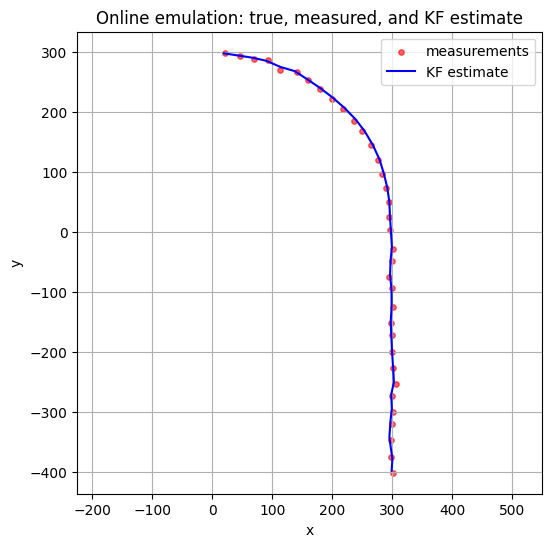

In [58]:
plot_trajectory(x_meas, y_meas,
                kx_est, ky_est)

In [72]:
def plot_velocities_estimate(t, vx_est, vy_est, vx_true=None, vy_true=None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))


    axes[0].plot(t, vx_est, 'b-', label='KF estimate')
    if vx_true is not None:
        axes[0].plot(t, vx_true, 'g--', label='true')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Vx (m/s)')
    axes[0].grid(True)
    axes[0].legend()
    axes[0].set_title('X-axis velocity')


    axes[1].plot(t, vy_est, 'b-', label='KF estimate')
    if vy_true is not None:
        axes[1].plot(t, vy_true, 'g--', label='true')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Vy (m/s)')
    axes[1].grid(True)
    axes[1].legend()
    axes[1].set_title('Y-axis velocity')

    plt.tight_layout()
    plt.show()

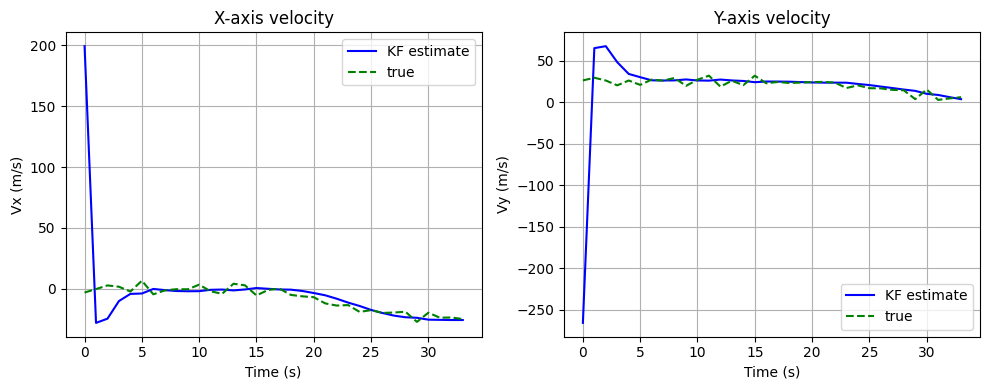

In [73]:
s_est, z_meas_hist = logger.get_stat(["s", "z"])
x_meas, y_meas = extract_xy_from_history(z_meas_hist)
kx_est, ky_est, vx_est, vy_est, ax_est, ay_est = extract_state_components(s_est)

vx_meas = np.diff(x_meas) / dt
vy_meas = np.diff(y_meas) / dt

v_points = len(vx_meas)
plot_velocities_estimate(np.arange(v_points) * dt, vx_est[:v_points], vy_est[:v_points], vx_meas, vy_meas)

## References

[GeoLife] Microsoft Corporation,   
*https://www.microsoft.com/en-us/download/details.aspx?id=52367*

[NickNair/MOT-KF] Nick Nair, *Multiple Object Tracking using Kalman Filter (GitHub repository)*,  
https://github.com/NickNair/Multiple-Object-Tracking-using-Kalman-Filter

[Bzarg] B. Zagar, *How a Kalman Filter Works, in Pictures*,  
https://www.bzarg.com/p/how-a-kalman-filter-works-in-pictures/

[CookieRobotics] *Kalman Filter for 2D Motion*, Cookie Robotics,  
https://cookierobotics.com/071/

[BilginEsme] Bilgin Esme, *Kalman Filter for Dummies*,  
https://bilgin.esme.org/bitsandbytes/kalmanfilterfordummies

[KalmanFilterNet] *Kalman Filter Explained Through Examples – Multi-Target Examples*,  
https://kalmanfilter.net/multiExamples.html

[RWTH-CV2] RWTH Aachen University, *Computer Vision 2: Kalman Filter* (lecture notes),  
https://www.vision.rwth-aachen.de/media/course/SS/2016/computer-vision-2/cv2_16-part05-kalman-filter.pdf

[TheKalmanFilter] *Kalman Filter Explained Simply*,  
https://thekalmanfilter.com/kalman-filter-explained-simply/

[FilterPy] R. Labbe, *FilterPy KalmanFilter Documentation*,  
https://filterpy.readthedocs.io/en/latest/kalman/KalmanFilter.html

[Fomightez] S. Fomightez, *Jupyter notebook examples for FilterPy / Kalman filtering* (GitHub Gist),  
https://gist.github.com/fomightez/e89bc19ec31d8ad1de1b8071c659e684

[WikipediaKF] *Kalman filter*, Wikipedia,  
https://en.wikipedia.org/wiki/Kalman_filter

[WelchBishop] G. Welch, G. Bishop, *An Introduction to the Kalman Filter*, UNC Chapel Hill, TR 95-041, 2006.  